In [1]:
# ============================================================
# PHASE 18 — CELL 1
# Imports
# ============================================================

from pathlib import Path
import os
import re
import json
import warnings
import hashlib
import time

import numpy as np
import pandas as pd

import tensorflow as tf

from IPython.display import display

warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)
print("Imports successful.")

TensorFlow version: 2.20.0
Imports successful.


In [2]:
# ============================================================
# PHASE 18 — CELL 2
# Project root
# ============================================================

PROJECT_ROOT = Path(
    r"D:\downloads\misleading-health-infographic-detection"
)

assert PROJECT_ROOT.exists(), (
    f"Project root does not exist:\n{PROJECT_ROOT}"
)

print("Project root:")
print(PROJECT_ROOT)

Project root:
D:\downloads\misleading-health-infographic-detection


In [3]:
# ============================================================
# PHASE 18 — CELL 3
# Output directories
# ============================================================

PHASE18_DIR = (
    PROJECT_ROOT /
    "outputs" /
    "phase18"
)

INFERENCE_DIR = (
    PHASE18_DIR /
    "inference"
)

CLAIMS_DIR = (
    PHASE18_DIR /
    "claims"
)

EVIDENCE_DIR = (
    PHASE18_DIR /
    "evidence"
)

EXPLANATIONS_DIR = (
    PHASE18_DIR /
    "explanations"
)

METRICS_DIR = (
    PHASE18_DIR /
    "metrics"
)

REPORT_DIR = (
    PHASE18_DIR /
    "reports"
)


for directory in [
    PHASE18_DIR,
    INFERENCE_DIR,
    CLAIMS_DIR,
    EVIDENCE_DIR,
    EXPLANATIONS_DIR,
    METRICS_DIR,
    REPORT_DIR
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


print("✓ Phase 18 directories created.")

✓ Phase 18 directories created.


In [5]:
# ============================================================
# PHASE 18 — CELL 4
# Input infographic
# ============================================================

TEST_IMAGE_DIR = (
    PROJECT_ROOT /
    "test_images"
)

TEST_IMAGE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# CHANGE THIS
# ------------------------------------------------------------

INPUT_IMAGE = (
    TEST_IMAGE_DIR /
    "test1.jpeg"
)


if not INPUT_IMAGE.exists():

    print(
        "INPUT IMAGE NOT FOUND"
    )

    print()
    print(
        "Put your infographic here:"
    )

    print(
        INPUT_IMAGE
    )

else:

    print(
        "✓ Input infographic found:"
    )

    print(
        INPUT_IMAGE
    )

✓ Input infographic found:
D:\downloads\misleading-health-infographic-detection\test_images\test1.jpeg


Image:
  Path   : D:\downloads\misleading-health-infographic-detection\test_images\test1.jpeg
  Format : JPEG
  Size   : (800, 1147)
  Mode   : RGB


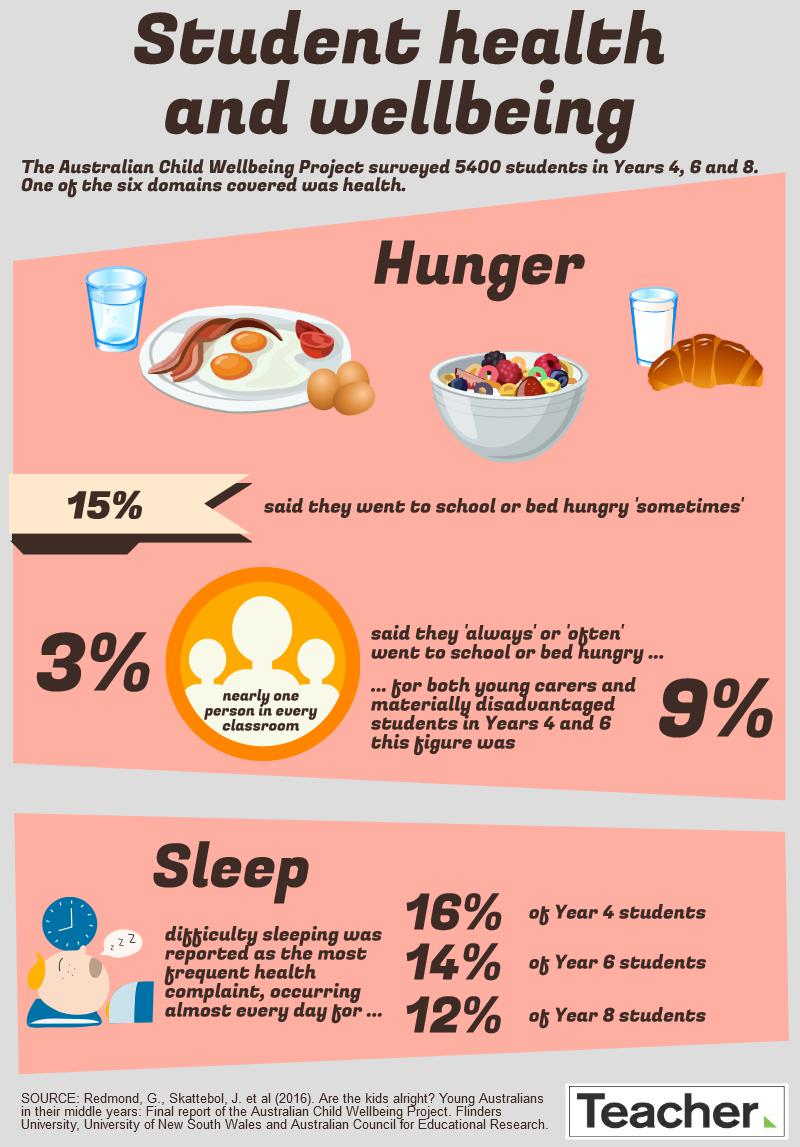

In [6]:
# ============================================================
# PHASE 18 — CELL 5
# Validate input image
# ============================================================

from PIL import Image


assert INPUT_IMAGE.exists(), (
    f"Image not found:\n{INPUT_IMAGE}"
)


image = Image.open(
    INPUT_IMAGE
)


print("Image:")
print(
    "  Path   :", INPUT_IMAGE
)

print(
    "  Format :", image.format
)

print(
    "  Size   :", image.size
)

print(
    "  Mode   :", image.mode
)


display(image)

In [7]:
# ============================================================
# PHASE 18 — CELL 6
# PaddleOCR initialization
# ============================================================

from paddleocr import PaddleOCR


print(
    "Initializing PaddleOCR..."
)


ocr = PaddleOCR(
    lang="en",
    device="cpu",
    enable_mkldnn=False
)


print(
    "✓ PaddleOCR initialized."
)

Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\poorv\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.


Initializing PaddleOCR...


Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\poorv\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\poorv\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\poorv\.paddlex\official_models\PP-OCRv6_medium_det`.
Creating model: ('PP-OCRv6_medium_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\poorv\.paddlex\official_models\PP-OCRv6_medium_rec`.


✓ PaddleOCR initialized.


In [8]:
# ============================================================
# PHASE 18 — CELL 7
# OCR inference
# ============================================================

print("=" * 70)
print("RUNNING OCR")
print("=" * 70)


ocr_result = ocr.predict(
    str(INPUT_IMAGE)
)


print(
    "OCR completed."
)


print(
    "Result type:",
    type(ocr_result)
)

RUNNING OCR
OCR completed.
Result type: <class 'list'>


In [9]:
# ============================================================
# PHASE 18 — CELL 8
# Extract OCR text
# ============================================================

def extract_ocr_text(result):

    texts = []

    def recursive_extract(obj):

        if obj is None:
            return

        # Dictionary
        if isinstance(obj, dict):

            for key, value in obj.items():

                key_lower = str(key).lower()

                if key_lower in {
                    "rec_texts",
                    "texts",
                    "text",
                    "rec_text"
                }:

                    if isinstance(value, (list, tuple)):

                        for item in value:

                            if str(item).strip():

                                texts.append(
                                    str(item).strip()
                                )

                    elif isinstance(value, str):

                        if value.strip():

                            texts.append(
                                value.strip()
                            )

                else:

                    recursive_extract(value)

            return

        # Lists / tuples
        if isinstance(obj, (list, tuple)):

            for item in obj:

                recursive_extract(item)

            return

        # Objects with rec_texts
        if hasattr(obj, "rec_texts"):

            values = getattr(
                obj,
                "rec_texts"
            )

            if values is not None:

                for value in values:

                    if str(value).strip():

                        texts.append(
                            str(value).strip()
                        )

            return

        # Objects with text
        if hasattr(obj, "text"):

            value = getattr(
                obj,
                "text"
            )

            if isinstance(value, str):

                if value.strip():

                    texts.append(
                        value.strip()
                    )


    recursive_extract(result)


    # Deduplicate while preserving order
    cleaned = []

    seen = set()

    for text in texts:

        normalized = re.sub(
            r"\s+",
            " ",
            text
        ).strip()

        if not normalized:
            continue

        key = normalized.lower()

        if key not in seen:

            seen.add(key)

            cleaned.append(
                normalized
            )


    return cleaned


ocr_lines = extract_ocr_text(
    ocr_result
)


ocr_text = "\n".join(
    ocr_lines
)


print("=" * 70)
print("OCR TEXT")
print("=" * 70)

print(
    ocr_text
)


print()
print(
    "OCR lines:",
    len(ocr_lines)
)

print(
    "OCR characters:",
    len(ocr_text)
)

OCR TEXT
Student health
and wellbeing
The Australian Child Wellbeing Project surveyed 5400 students in Years 4, 6 and 8.
One of the six domains covered was health.
Hunger
15%
said they went to school or bed hungry 'sometimes'
3%
said they 'always'or 'often'
went to school or bed hungry ...
... for both young carers and
9%
nearly one
person in every
materially disadvantaged
classroom
students in Years 4 and 6
this figure was
Sleep
16%
of Year 4 students
difficulty sleeping was
reported as the most
14%
frequent health
of Year 6 students
complaint, occurring
almost every day for
12%
of Year 8 students
SOURCE: Redmond, G., Skattebol, J. et al (2016). Are the kids alright? Young Australians
in their middle years: Final report of the Australian Child Wellbeing Project Flinders

OCR lines: 32
OCR characters: 772


In [10]:
# ============================================================
# PHASE 18 — CELL 9
# Save OCR output
# ============================================================

ocr_output = {

    "input_image": str(
        INPUT_IMAGE
    ),

    "ocr_success": bool(
        len(ocr_text.strip()) > 0
    ),

    "ocr_text": ocr_text,

    "ocr_lines": ocr_lines,

    "num_text_lines": len(
        ocr_lines
    ),

    "ocr_char_count": len(
        ocr_text
    ),

    "ocr_word_count": len(
        ocr_text.split()
    )
}


OCR_OUTPUT_PATH = (
    INFERENCE_DIR /
    "ocr_result.json"
)


with open(
    OCR_OUTPUT_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        ocr_output,
        f,
        indent=4,
        ensure_ascii=False
    )


print(
    "✓ OCR result saved:"
)

print(
    OCR_OUTPUT_PATH
)

✓ OCR result saved:
D:\downloads\misleading-health-infographic-detection\outputs\phase18\inference\ocr_result.json


In [11]:
# ============================================================
# PHASE 18 — CELL 10
# OCR normalization
# ============================================================

def normalize_ocr_text(text):

    if text is None:
        return ""

    text = str(text)

    text = re.sub(
        r"[\r\n]+",
        ". ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    text = re.sub(
        r"[.]{2,}",
        ".",
        text
    )

    text = re.sub(
        r"[,]{2,}",
        ",",
        text
    )

    return text.strip()


normalized_text = normalize_ocr_text(
    ocr_text
)


print(
    normalized_text
)

Student health. and wellbeing. The Australian Child Wellbeing Project surveyed 5400 students in Years 4, 6 and 8. One of the six domains covered was health. Hunger. 15%. said they went to school or bed hungry 'sometimes'. 3%. said they 'always'or 'often'. went to school or bed hungry . . for both young carers and. 9%. nearly one. person in every. materially disadvantaged. classroom. students in Years 4 and 6. this figure was. Sleep. 16%. of Year 4 students. difficulty sleeping was. reported as the most. 14%. frequent health. of Year 6 students. complaint, occurring. almost every day for. 12%. of Year 8 students. SOURCE: Redmond, G., Skattebol, J. et al (2016). Are the kids alright? Young Australians. in their middle years: Final report of the Australian Child Wellbeing Project Flinders


In [12]:
# ============================================================
# PHASE 18 — CELL 11
# Health concept dictionary
# ============================================================

HEALTH_CONCEPTS = {

    "disease_conditions": [
        "disease",
        "diseases",
        "diabetes",
        "cancer",
        "heart disease",
        "cardiovascular",
        "hypertension",
        "high blood pressure",
        "low blood pressure",
        "obesity",
        "asthma",
        "infection",
        "infections",
        "flu",
        "covid",
        "covid-19",
        "stroke",
        "arthritis",
        "kidney disease",
        "liver disease"
    ],

    "symptoms": [
        "symptom",
        "symptoms",
        "pain",
        "fatigue",
        "fever",
        "headache",
        "nausea",
        "dizziness",
        "cough",
        "swelling",
        "inflammation"
    ],

    "treatments": [
        "treatment",
        "therapy",
        "medicine",
        "medication",
        "drug",
        "drugs",
        "vaccine",
        "vaccination",
        "surgery",
        "antibiotic"
    ],

    "nutrition": [
        "diet",
        "food",
        "foods",
        "nutrition",
        "nutrient",
        "vitamin",
        "mineral",
        "protein",
        "carbohydrate",
        "fat",
        "sugar",
        "salt",
        "calories"
    ],

    "lifestyle": [
        "exercise",
        "physical activity",
        "walking",
        "sleep",
        "stress",
        "smoking",
        "alcohol",
        "weight loss",
        "weight gain"
    ]
}


ALL_HEALTH_TERMS = sorted(
    {
        term.lower()
        for terms in HEALTH_CONCEPTS.values()
        for term in terms
    },
    key=len,
    reverse=True
)


print(
    "Health terms:",
    len(ALL_HEALTH_TERMS)
)

Health terms: 63


In [13]:
# ============================================================
# PHASE 18 — CELL 12
# Claim cues
# ============================================================

CLAIM_CUES = [

    "cause",
    "causes",
    "caused",
    "lead to",
    "leads to",
    "result in",
    "results in",

    "increase",
    "increases",
    "increased",

    "decrease",
    "decreases",
    "decreased",

    "reduce",
    "reduces",
    "reduced",

    "lower",
    "lowers",
    "lowering",

    "higher",
    "raise",
    "raises",

    "boost",
    "boosts",

    "prevent",
    "prevents",
    "prevention",

    "cure",
    "cures",
    "treat",
    "treats",

    "improve",
    "improves",

    "protect",
    "protects",

    "risk",
    "risks",

    "associated with",
    "linked to",

    "recommended",
    "recommend",
    "should",
    "must",

    "proven",
    "proves",
    "guaranteed",

    "effective",
    "safe",

    "dangerous"
]


RECOMMENDATION_CUES = [
    "should",
    "must",
    "recommend",
    "recommended",
    "avoid",
    "consume",
    "eat",
    "take",
    "drink",
    "use"
]


print(
    "Claim cues:",
    len(CLAIM_CUES)
)

Claim cues: 49


In [14]:
# ============================================================
# PHASE 18 — CELL 13
# Sentence segmentation
# ============================================================

def split_sentences(text):

    if not text:
        return []

    text = re.sub(
        r"[\r\n]+",
        ". ",
        text
    )

    parts = re.split(
        r"(?<=[.!?])\s+"
        r"|;\s+"
        r"|\|\s+",
        text
    )

    sentences = []

    for part in parts:

        part = part.strip(
            " .,:;|-"
        )

        if len(part) >= 8:

            sentences.append(
                part
            )

    return sentences


sentences = split_sentences(
    normalized_text
)


print(
    "Detected sentences:",
    len(sentences)
)

for i, sentence in enumerate(
    sentences,
    start=1
):

    print(
        f"{i}. {sentence}"
    )

Detected sentences: 27
1. Student health
2. and wellbeing
3. The Australian Child Wellbeing Project surveyed 5400 students in Years 4, 6 and 8
4. One of the six domains covered was health
5. said they went to school or bed hungry 'sometimes'
6. said they 'always'or 'often'
7. went to school or bed hungry
8. for both young carers and
9. nearly one
10. person in every
11. materially disadvantaged
12. classroom
13. students in Years 4 and 6
14. this figure was
15. of Year 4 students
16. difficulty sleeping was
17. reported as the most
18. frequent health
19. of Year 6 students
20. complaint, occurring
21. almost every day for
22. of Year 8 students
23. SOURCE: Redmond, G., Skattebol, J
24. et al (2016)
25. Are the kids alright?
26. Young Australians
27. in their middle years: Final report of the Australian Child Wellbeing Project Flinders


In [15]:
# ============================================================
# PHASE 18 — CELL 14
# Health term extraction
# ============================================================

def detect_health_terms(text):

    text_lower = text.lower()

    found = []

    for term in ALL_HEALTH_TERMS:

        if term in text_lower:

            found.append(
                term
            )

    return list(
        dict.fromkeys(found)
    )


def detect_health_categories(text):

    text_lower = text.lower()

    categories = []

    for category, terms in HEALTH_CONCEPTS.items():

        if any(
            term.lower() in text_lower
            for term in terms
        ):

            categories.append(
                category
            )

    return categories

In [16]:
# ============================================================
# PHASE 18 — CELL 15
# Quantitative value extraction
# ============================================================

def extract_quantitative_values(text):

    patterns = [

        r"\b\d+(?:\.\d+)?\s*%",
        r"\b\d+(?:\.\d+)?\s*(?:mg|g|kg|mcg|µg)",
        r"\b\d+(?:\.\d+)?\s*(?:ml|l|liters?|litres?)",
        r"\b\d+(?:\.\d+)?\s*(?:hours?|days?|weeks?|months?|years?)",
        r"\b\d+(?:\.\d+)?\s*(?:times?|x)",
        r"\b\d+(?:\.\d+)?\b"
    ]

    values = []

    for pattern in patterns:

        matches = re.findall(
            pattern,
            text,
            flags=re.IGNORECASE
        )

        values.extend(
            matches
        )

    return list(
        dict.fromkeys(
            values
        )
    )

In [17]:
# ============================================================
# PHASE 18 — CELL 16
# Medical claim candidate extraction
# ============================================================

def score_claim_candidate(sentence):

    text = sentence.lower()

    health_terms = detect_health_terms(
        sentence
    )

    health_categories = detect_health_categories(
        sentence
    )

    score = 0

    if health_terms:
        score += 2

    if health_categories:
        score += 1

    if any(
        cue in text
        for cue in CLAIM_CUES
    ):
        score += 2

    if extract_quantitative_values(
        sentence
    ):
        score += 1

    if len(sentence.split()) >= 8:
        score += 1

    return {

        "score": score,

        "health_terms": health_terms,

        "health_categories": health_categories,

        "quantitative_values":
            extract_quantitative_values(
                sentence
            )
    }


claim_records = []


for index, sentence in enumerate(
    sentences
):

    analysis = score_claim_candidate(
        sentence
    )

    if analysis["score"] >= 3:

        claim_records.append({

            "claim_index": index,

            "claim_text": sentence,

            "candidate_score":
                analysis["score"],

            "health_terms":
                analysis["health_terms"],

            "health_categories":
                analysis["health_categories"],

            "quantitative_values":
                analysis["quantitative_values"]
        })


print(
    "Candidate claims:",
    len(claim_records)
)


for record in claim_records:

    print()
    print(
        record["claim_text"]
    )

Candidate claims: 1

difficulty sleeping was


In [18]:
# ============================================================
# PHASE 18 — CELL 17
# Claim type classification
# ============================================================

def classify_claim_type(text):

    text_lower = text.lower()

    if any(
        cue in text_lower
        for cue in RECOMMENDATION_CUES
    ):

        return "recommendation"

    if any(
        word in text_lower
        for word in [
            "risk",
            "cause",
            "causes",
            "lead to",
            "results in",
            "associated with",
            "linked to"
        ]
    ):

        return "causal_or_risk"

    if any(
        word in text_lower
        for word in [
            "%",
            "increase",
            "decrease",
            "higher",
            "lower",
            "times"
        ]
    ):

        return "quantitative"

    if any(
        word in text_lower
        for word in [
            "cure",
            "treat",
            "prevents",
            "prevent",
            "effective"
        ]
    ):

        return "treatment_or_prevention"

    return "health_fact"


for record in claim_records:

    record["claim_type"] = (
        classify_claim_type(
            record["claim_text"]
        )
    )


display(
    pd.DataFrame(
        claim_records
    )
)

,claim_index,claim_text,candidate_score,health_terms,health_categories,quantitative_values,claim_type
0,15,difficulty sleeping was,3,[sleep],[lifestyle],[],health_fact


In [19]:
# ============================================================
# PHASE 18 — CELL 18
# Claim IDs
# ============================================================

for i, record in enumerate(
    claim_records
):

    record["claim_id"] = (
        f"phase18_claim_{i+1:04d}"
    )


print(
    "Claims generated:",
    len(claim_records)
)

Claims generated: 1


In [20]:
# ============================================================
# PHASE 18 — CELL 19
# Save extracted claims
# ============================================================

CLAIMS_OUTPUT_PATH = (
    CLAIMS_DIR /
    "claims.json"
)


with open(
    CLAIMS_OUTPUT_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        claim_records,
        f,
        indent=4,
        ensure_ascii=False
    )


claims_df = pd.DataFrame(
    claim_records
)


CLAIMS_CSV_PATH = (
    CLAIMS_DIR /
    "claims.csv"
)


claims_df.to_csv(
    CLAIMS_CSV_PATH,
    index=False,
    encoding="utf-8-sig"
)


print(
    "✓ Claims saved:"
)

print(
    CLAIMS_OUTPUT_PATH
)

print(
    CLAIMS_CSV_PATH
)

✓ Claims saved:
D:\downloads\misleading-health-infographic-detection\outputs\phase18\claims\claims.json
D:\downloads\misleading-health-infographic-detection\outputs\phase18\claims\claims.csv


In [21]:
# ============================================================
# PHASE 18 — CELL 20
# Load Phase 17 / Phase 11 multimodal model
# ============================================================

from tensorflow.keras import layers, Model


PHASE11_TRAIN = (
    PROJECT_ROOT /
    "outputs" /
    "phase11" /
    "datasets" /
    "final_train.csv"
)

PHASE11_WEIGHTS = (
    PROJECT_ROOT /
    "outputs" /
    "phase11" /
    "checkpoints" /
    "best_multimodal_model.weights.h5"
)


assert PHASE11_TRAIN.exists(), (
    f"Phase 11 training data not found:\n"
    f"{PHASE11_TRAIN}"
)

assert PHASE11_WEIGHTS.exists(), (
    f"Multimodal weights not found:\n"
    f"{PHASE11_WEIGHTS}"
)


phase11_train_df = pd.read_csv(
    PHASE11_TRAIN,
    encoding="utf-8-sig"
)


print(
    "Phase 11 training rows:",
    len(phase11_train_df)
)

Phase 11 training rows: 4016


In [22]:
# ============================================================
# PHASE 18 — CELL 21
# Reconstruct multimodal architecture
# ============================================================

IMG_SIZE = (
    224,
    224
)

MAX_TOKENS = 20000

SEQUENCE_LENGTH = 300


# ------------------------------------------------------------
# Image branch
# ------------------------------------------------------------

image_input = layers.Input(
    shape=(224, 224, 3),
    name="image"
)


base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)


base_model.trainable = False


image_features = base_model(
    image_input,
    training=False
)

image_features = layers.GlobalAveragePooling2D()(
    image_features
)

image_features = layers.Dense(
    128,
    activation="relu"
)(
    image_features
)


# ------------------------------------------------------------
# Text branch
# ------------------------------------------------------------

text_input = layers.Input(
    shape=(),
    dtype=tf.string,
    name="text"
)


text_vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH,
    standardize="lower_and_strip_punctuation"
)


train_texts_phase11 = (
    phase11_train_df["text"]
    .fillna("")
    .astype(str)
    .values
)


text_vectorizer.adapt(
    tf.data.Dataset
    .from_tensor_slices(
        train_texts_phase11
    )
    .batch(256)
)


text_tokens = text_vectorizer(
    text_input
)


text_embedding = layers.Embedding(
    input_dim=MAX_TOKENS,
    output_dim=128,
    mask_zero=True
)(
    text_tokens
)


text_features = layers.Bidirectional(
    layers.LSTM(64)
)(
    text_embedding
)


text_features = layers.Dense(
    128,
    activation="relu"
)(
    text_features
)


# ------------------------------------------------------------
# Fusion
# ------------------------------------------------------------

combined = layers.Concatenate()([
    image_features,
    text_features
])


combined = layers.Dense(
    128,
    activation="relu"
)(
    combined
)

combined = layers.Dropout(
    0.4
)(
    combined
)

combined = layers.Dense(
    64,
    activation="relu"
)(
    combined
)

combined = layers.Dropout(
    0.3
)(
    combined
)


output = layers.Dense(
    1,
    activation="sigmoid"
)(
    combined
)


multimodal_inference_model = Model(
    inputs={
        "image": image_input,
        "text": text_input
    },
    outputs=output
)


multimodal_inference_model.load_weights(
    PHASE11_WEIGHTS
)


print(
    "✓ Multimodal weights loaded successfully."
)

✓ Multimodal weights loaded successfully.


In [23]:
# ============================================================
# PHASE 18 — CELL 22
# Load validated multimodal threshold
# ============================================================

PHASE17_COMPARISON = (
    PROJECT_ROOT /
    "outputs" /
    "phase17" /
    "metrics" /
    "model_comparison.csv"
)


assert PHASE17_COMPARISON.exists(), (
    f"Phase 17 comparison file not found:\n"
    f"{PHASE17_COMPARISON}"
)


phase17_comparison = pd.read_csv(
    PHASE17_COMPARISON
)


multimodal_row = (
    phase17_comparison[
        phase17_comparison["model"]
        == "multimodal"
    ]
    .iloc[0]
)


MULTIMODAL_THRESHOLD = float(
    multimodal_row["threshold"]
)


print(
    "Validated multimodal threshold:",
    MULTIMODAL_THRESHOLD
)

Validated multimodal threshold: 0.11


In [24]:
# ============================================================
# PHASE 18 — CELL 23
# Final multimodal prediction
# ============================================================

image_array = tf.io.read_file(
    str(INPUT_IMAGE)
)

image_array = tf.image.decode_image(
    image_array,
    channels=3,
    expand_animations=False
)

image_array.set_shape(
    [None, None, 3]
)

image_array = tf.image.resize(
    image_array,
    IMG_SIZE
)

image_array = tf.cast(
    image_array,
    tf.float32
)

image_array = tf.expand_dims(
    image_array,
    axis=0
)


text_array = tf.constant([
    normalized_text
])


prediction_probability = (
    multimodal_inference_model.predict(
        {
            "image": image_array,
            "text": text_array
        },
        verbose=0
    )[0][0]
)


prediction_probability = float(
    prediction_probability
)


prediction_label = int(
    prediction_probability
    >= MULTIMODAL_THRESHOLD
)


prediction_name = (
    "misleading"
    if prediction_label == 1
    else "not_misleading"
)


print("=" * 70)
print("MODEL PREDICTION")
print("=" * 70)

print(
    "Probability:",
    f"{prediction_probability:.4f}"
)

print(
    "Threshold:",
    f"{MULTIMODAL_THRESHOLD:.4f}"
)

print(
    "Prediction:",
    prediction_name
)

MODEL PREDICTION
Probability: 0.5334
Threshold: 0.1100
Prediction: misleading


In [25]:
# ============================================================
# PHASE 18 — CELL 24
# Deception type classification
# ============================================================

def classify_deception_type(
    claim_text,
    quantitative_values
):

    text = claim_text.lower()

    if (
        quantitative_values
        and any(
            word in text
            for word in [
                "increase",
                "decrease",
                "risk",
                "%",
                "times"
            ]
        )
    ):

        return "quantitative_misrepresentation"

    if any(
        word in text
        for word in [
            "proven",
            "guaranteed",
            "always",
            "never",
            "100%"
        ]
    ):

        return "overclaiming"

    if any(
        word in text
        for word in [
            "cure",
            "cures",
            "guaranteed",
            "completely prevent"
        ]
    ):

        return "unsupported_cure_or_prevention"

    if any(
        word in text
        for word in [
            "should",
            "must",
            "avoid",
            "recommended"
        ]
    ):

        return "prescriptive_claim"

    if any(
        word in text
        for word in [
            "cause",
            "causes",
            "leads to",
            "results in"
        ]
    ):

        return "causal_claim"

    return "general_health_claim"


for record in claim_records:

    record["deception_type"] = (
        classify_deception_type(
            record["claim_text"],
            record["quantitative_values"]
        )
    )


display(
    pd.DataFrame(
        claim_records
    )[
        [
            "claim_id",
            "claim_text",
            "claim_type",
            "deception_type"
        ]
    ]
)

,claim_id,claim_text,claim_type,deception_type
0,phase18_claim_0001,difficulty sleeping was,health_fact,general_health_claim


In [26]:
# ============================================================
# PHASE 18 — CELL 25
# PubMed evidence retrieval
# ============================================================

import requests


PUBMED_SEARCH_URL = (
    "https://eutils.ncbi.nlm.nih.gov/"
    "entrez/eutils/esearch.fcgi"
)

PUBMED_SUMMARY_URL = (
    "https://eutils.ncbi.nlm.nih.gov/"
    "entrez/eutils/esummary.fcgi"
)


def tokenize(text):

    return set(
        re.findall(
            r"\b[a-zA-Z]{3,}\b",
            text.lower()
        )
    )


def lexical_relevance(
    claim_text,
    evidence_text
):

    claim_tokens = tokenize(
        claim_text
    )

    evidence_tokens = tokenize(
        evidence_text
    )

    if not claim_tokens:
        return 0.0

    overlap = (
        claim_tokens
        & evidence_tokens
    )

    return len(overlap) / len(
        claim_tokens
    )


def search_pubmed(
    claim_text,
    max_results=5
):

    params = {

        "db": "pubmed",

        "term": claim_text,

        "retmax": max_results,

        "retmode": "json"
    }


    response = requests.get(
        PUBMED_SEARCH_URL,
        params=params,
        timeout=30
    )


    response.raise_for_status()


    data = response.json()


    ids = (
        data
        .get("esearchresult", {})
        .get("idlist", [])
    )


    if not ids:
        return []


    summary_params = {

        "db": "pubmed",

        "id": ",".join(ids),

        "retmode": "json"
    }


    summary_response = requests.get(
        PUBMED_SUMMARY_URL,
        params=summary_params,
        timeout=30
    )


    summary_response.raise_for_status()


    summary_data = (
        summary_response
        .json()
        .get("result", {})
    )


    records = []


    for pmid in ids:

        item = summary_data.get(
            pmid,
            {}
        )

        title = item.get(
            "title",
            ""
        )

        record = {

            "source": "PubMed",

            "pmid": pmid,

            "title": title,

            "url":
                f"https://pubmed.ncbi.nlm.nih.gov/{pmid}/",

            "relevance_score":
                lexical_relevance(
                    claim_text,
                    title
                )
        }

        records.append(
            record
        )


    return records

In [27]:
# ============================================================
# PHASE 18 — CELL 26
# Retrieve evidence
# ============================================================

all_evidence = []


for record in claim_records:

    claim_id = record[
        "claim_id"
    ]

    claim_text = record[
        "claim_text"
    ]


    print()
    print(
        "Searching evidence for:"
    )

    print(
        claim_text
    )


    try:

        evidence = search_pubmed(
            claim_text,
            max_results=5
        )


    except Exception as e:

        print(
            "Evidence retrieval error:",
            e
        )

        evidence = []


    for rank, item in enumerate(
        evidence,
        start=1
    ):

        item["claim_id"] = (
            claim_id
        )

        item["rank"] = rank

        all_evidence.append(
            item
        )


    time.sleep(
        0.35
    )


evidence_df = pd.DataFrame(
    all_evidence
)


print()
print(
    "=" * 70
)

print(
    "Evidence records:",
    len(evidence_df)
)


display(
    evidence_df
)


Searching evidence for:
difficulty sleeping was

Evidence records: 5


,source,pmid,title,url,relevance_score,claim_id,rank
0,PubMed,42763459,Shank3 mutation disrupts the molecular signatu...,https://pubmed.ncbi.nlm.nih.gov/42763459/,0.0,phase18_claim_0001,1
1,PubMed,42763428,Banxia Shumi Decoction Alleviates PCPA-Induced...,https://pubmed.ncbi.nlm.nih.gov/42763428/,0.0,phase18_claim_0001,2
2,PubMed,42763373,Sleep duration and oral functional impairment:...,https://pubmed.ncbi.nlm.nih.gov/42763373/,0.0,phase18_claim_0001,3
3,PubMed,42763108,Happiness Toolkit in a paediatric outpatient s...,https://pubmed.ncbi.nlm.nih.gov/42763108/,0.0,phase18_claim_0001,4
4,PubMed,42762164,Correlates of Subjective Cognitive Impairment ...,https://pubmed.ncbi.nlm.nih.gov/42762164/,0.0,phase18_claim_0001,5


In [28]:
# ============================================================
# PHASE 18 — CELL 27
# Evidence relevance classification
# ============================================================

def classify_relevance(score):

    if score >= 0.60:
        return "HIGH"

    if score >= 0.30:
        return "MODERATE"

    if score > 0:
        return "LOW"

    return "NO_TEXTUAL_EVIDENCE"


if len(evidence_df) > 0:

    evidence_df[
        "relevance_class"
    ] = evidence_df[
        "relevance_score"
    ].apply(
        classify_relevance
    )


    display(
        evidence_df[
            [
                "claim_id",
                "rank",
                "title",
                "relevance_score",
                "relevance_class"
            ]
        ]
    )

,claim_id,rank,title,relevance_score,relevance_class
0,phase18_claim_0001,1,Shank3 mutation disrupts the molecular signatu...,0.0,NO_TEXTUAL_EVIDENCE
1,phase18_claim_0001,2,Banxia Shumi Decoction Alleviates PCPA-Induced...,0.0,NO_TEXTUAL_EVIDENCE
2,phase18_claim_0001,3,Sleep duration and oral functional impairment:...,0.0,NO_TEXTUAL_EVIDENCE
3,phase18_claim_0001,4,Happiness Toolkit in a paediatric outpatient s...,0.0,NO_TEXTUAL_EVIDENCE
4,phase18_claim_0001,5,Correlates of Subjective Cognitive Impairment ...,0.0,NO_TEXTUAL_EVIDENCE


In [29]:
# ============================================================
# PHASE 18 — CELL 28
# Save evidence
# ============================================================

EVIDENCE_CSV = (
    EVIDENCE_DIR /
    "retrieved_evidence.csv"
)


EVIDENCE_JSON = (
    EVIDENCE_DIR /
    "retrieved_evidence.json"
)


evidence_df.to_csv(
    EVIDENCE_CSV,
    index=False,
    encoding="utf-8-sig"
)


with open(
    EVIDENCE_JSON,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        evidence_df.to_dict(
            orient="records"
        ),
        f,
        indent=4,
        ensure_ascii=False
    )


print(
    "✓ Evidence saved."
)

print(
    EVIDENCE_CSV
)

print(
    EVIDENCE_JSON
)

✓ Evidence saved.
D:\downloads\misleading-health-infographic-detection\outputs\phase18\evidence\retrieved_evidence.csv
D:\downloads\misleading-health-infographic-detection\outputs\phase18\evidence\retrieved_evidence.json


In [30]:
# ============================================================
# PHASE 18 — CELL 29
# Evidence-grounded explanations
# ============================================================

explanations = []


for record in claim_records:

    claim_id = record[
        "claim_id"
    ]

    claim_text = record[
        "claim_text"
    ]


    if len(evidence_df) > 0:

        claim_evidence = (
            evidence_df[
                evidence_df["claim_id"]
                == claim_id
            ]
            .sort_values(
                "relevance_score",
                ascending=False
            )
        )

    else:

        claim_evidence = (
            pd.DataFrame()
        )


    if len(claim_evidence) == 0:

        explanation = (
            "No retrieved evidence was found "
            "for this claim."
        )

    else:

        top = claim_evidence.iloc[0]

        explanation = (
            f"Claim: {claim_text}\n\n"
            f"Retrieved evidence: "
            f"{top['title']}\n\n"
            f"Source: {top['source']}\n"
            f"Relevance: "
            f"{top['relevance_score']:.3f}\n\n"
            "This retrieval score indicates textual "
            "relevance to the claim; it does not by "
            "itself establish that the claim is true "
            "or false."
        )


    explanations.append({

        "claim_id":
            claim_id,

        "claim_text":
            claim_text,

        "claim_type":
            record["claim_type"],

        "deception_type":
            record["deception_type"],

        "explanation":
            explanation
    })


explanations_df = pd.DataFrame(
    explanations
)


display(
    explanations_df
)

,claim_id,claim_text,claim_type,deception_type,explanation
0,phase18_claim_0001,difficulty sleeping was,health_fact,general_health_claim,Claim: difficulty sleeping was\n\nRetrieved ev...


In [31]:
# ============================================================
# PHASE 18 — CELL 30
# Save explanations
# ============================================================

EXPLANATION_CSV = (
    EXPLANATIONS_DIR /
    "claim_explanations.csv"
)


EXPLANATION_JSON = (
    EXPLANATIONS_DIR /
    "claim_explanations.json"
)


explanations_df.to_csv(
    EXPLANATION_CSV,
    index=False,
    encoding="utf-8-sig"
)


with open(
    EXPLANATION_JSON,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        explanations,
        f,
        indent=4,
        ensure_ascii=False
    )


print(
    "✓ Explanations saved."
)

✓ Explanations saved.


In [32]:
# ============================================================
# PHASE 18 — CELL 31
# Final inference result
# ============================================================

final_result = {

    "phase": 18,

    "input": {

        "image_path":
            str(INPUT_IMAGE),

        "image_name":
            INPUT_IMAGE.name
    },

    "ocr": {

        "success":
            bool(
                len(ocr_text.strip()) > 0
            ),

        "text":
            ocr_text,

        "num_lines":
            len(ocr_lines),

        "num_characters":
            len(ocr_text)
    },

    "claims": {

        "count":
            len(claim_records),

        "records":
            claim_records
    },

    "model_prediction": {

        "model":
            "Phase 11 multimodal model",

        "probability":
            prediction_probability,

        "threshold":
            MULTIMODAL_THRESHOLD,

        "label":
            prediction_label,

        "classification":
            prediction_name
    },

    "evidence": {

        "count":
            len(evidence_df),

        "source":
            "PubMed"
    },

    "explanations":
        explanations
}


FINAL_JSON_PATH = (
    INFERENCE_DIR /
    "phase18_final_result.json"
)


with open(
    FINAL_JSON_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_result,
        f,
        indent=4,
        ensure_ascii=False
    )


print(
    "✓ Final result saved:"
)

print(
    FINAL_JSON_PATH
)

✓ Final result saved:
D:\downloads\misleading-health-infographic-detection\outputs\phase18\inference\phase18_final_result.json


In [33]:
# ============================================================
# PHASE 18 — CELL 32
# Human-readable inference report
# ============================================================

REPORT_PATH = (
    REPORT_DIR /
    "phase18_inference_report.txt"
)


with open(
    REPORT_PATH,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "PHASE 18 — END-TO-END INFERENCE REPORT\n"
    )

    f.write(
        "=" * 70 + "\n\n"
    )


    f.write(
        "INPUT IMAGE\n"
    )

    f.write(
        f"{INPUT_IMAGE}\n\n"
    )


    f.write(
        "OCR TEXT\n"
    )

    f.write(
        "-" * 70 + "\n"
    )

    f.write(
        ocr_text
    )

    f.write(
        "\n\n"
    )


    f.write(
        "FINAL MODEL PREDICTION\n"
    )

    f.write(
        "-" * 70 + "\n"
    )

    f.write(
        f"Probability : "
        f"{prediction_probability:.4f}\n"
    )

    f.write(
        f"Threshold   : "
        f"{MULTIMODAL_THRESHOLD:.4f}\n"
    )

    f.write(
        f"Prediction  : "
        f"{prediction_name}\n\n"
    )


    f.write(
        "CLAIMS\n"
    )

    f.write(
        "-" * 70 + "\n"
    )


    for record in claim_records:

        f.write(
            f"\n[{record['claim_id']}]\n"
        )

        f.write(
            f"Claim: "
            f"{record['claim_text']}\n"
        )

        f.write(
            f"Claim type: "
            f"{record['claim_type']}\n"
        )

        f.write(
            f"Deception type: "
            f"{record['deception_type']}\n"
        )

        f.write(
            f"Candidate score: "
            f"{record['candidate_score']}\n"
        )


    f.write(
        "\n\n"
    )


    f.write(
        "EVIDENCE\n"
    )

    f.write(
        "-" * 70 + "\n"
    )


    f.write(
        f"Retrieved evidence records: "
        f"{len(evidence_df)}\n"
    )

    f.write(
        "Source: PubMed\n\n"
    )


    if len(evidence_df) > 0:

        for _, row in (
            evidence_df
            .sort_values(
                "relevance_score",
                ascending=False
            )
            .iterrows()
        ):

            f.write(
                f"[{row['claim_id']}] "
                f"{row['title']}\n"
            )

            f.write(
                f"Relevance: "
                f"{row['relevance_score']:.3f}\n"
            )

            f.write(
                f"URL: "
                f"{row['url']}\n\n"
            )


    f.write(
        "\nIMPORTANT LIMITATION\n"
    )

    f.write(
        "-" * 70 + "\n"
    )

    f.write(
        "The evidence retrieval score represents textual "
        "relevance and is not itself a medical truth "
        "verification score. The Phase 16 deception "
        "classification is a descriptive rule-based "
        "candidate classification.\n"
    )


print(
    "✓ Report generated:"
)

print(
    REPORT_PATH
)

✓ Report generated:
D:\downloads\misleading-health-infographic-detection\outputs\phase18\reports\phase18_inference_report.txt


In [34]:
# ============================================================
# PHASE 18 — CELL 33
# Final artifact verification
# ============================================================

expected_files = [

    INFERENCE_DIR /
    "ocr_result.json",

    CLAIMS_DIR /
    "claims.json",

    CLAIMS_DIR /
    "claims.csv",

    EVIDENCE_DIR /
    "retrieved_evidence.csv",

    EVIDENCE_DIR /
    "retrieved_evidence.json",

    EXPLANATIONS_DIR /
    "claim_explanations.csv",

    EXPLANATIONS_DIR /
    "claim_explanations.json",

    INFERENCE_DIR /
    "phase18_final_result.json",

    REPORT_DIR /
    "phase18_inference_report.txt"
]


verification = []


for path in expected_files:

    verification.append({

        "artifact":
            str(path),

        "exists":
            path.exists(),

        "size_bytes":
            path.stat().st_size
            if path.exists()
            else 0
    })


verification_df = pd.DataFrame(
    verification
)


display(
    verification_df
)


missing = verification_df[
    ~verification_df["exists"]
]


if len(missing) == 0:

    print()
    print("=" * 70)
    print("✓ PHASE 18 END-TO-END INFERENCE COMPLETED")
    print("=" * 70)

else:

    print()
    print(
        "Missing artifacts:"
    )

    display(
        missing
    )

,artifact,exists,size_bytes
0,D:\downloads\misleading-health-infographic-det...,True,2223
1,D:\downloads\misleading-health-infographic-det...,True,372
2,D:\downloads\misleading-health-infographic-det...,True,202
3,D:\downloads\misleading-health-infographic-det...,True,1190
4,D:\downloads\misleading-health-infographic-det...,True,2104
5,D:\downloads\misleading-health-infographic-det...,True,438
6,D:\downloads\misleading-health-infographic-det...,True,530
7,D:\downloads\misleading-health-infographic-det...,True,2610
8,D:\downloads\misleading-health-infographic-det...,True,2966



✓ PHASE 18 END-TO-END INFERENCE COMPLETED


In [35]:
# ============================================================
# PHASE 18 — CELL 34
# Final summary
# ============================================================

print()
print("=" * 70)
print("PHASE 18 — END-TO-END RESULT")
print("=" * 70)

print()

print(
    "Input image:"
)

print(
    INPUT_IMAGE.name
)

print()

print(
    "OCR characters:"
)

print(
    len(ocr_text)
)

print()

print(
    "Claims extracted:"
)

print(
    len(claim_records)
)

print()

print(
    "Evidence records:"
)

print(
    len(evidence_df)
)

print()

print(
    "Multimodal probability:"
)

print(
    f"{prediction_probability:.4f}"
)

print()

print(
    "Validated threshold:"
)

print(
    f"{MULTIMODAL_THRESHOLD:.4f}"
)

print()

print(
    "Final classification:"
)

print(
    prediction_name
)

print()

print(
    "Final JSON:"
)

print(
    FINAL_JSON_PATH
)

print()

print(
    "Report:"
)

print(
    REPORT_PATH
)

print()
print("=" * 70)


PHASE 18 — END-TO-END RESULT

Input image:
test1.jpeg

OCR characters:
772

Claims extracted:
1

Evidence records:
5

Multimodal probability:
0.5334

Validated threshold:
0.1100

Final classification:
misleading

Final JSON:
D:\downloads\misleading-health-infographic-detection\outputs\phase18\inference\phase18_final_result.json

Report:
D:\downloads\misleading-health-infographic-detection\outputs\phase18\reports\phase18_inference_report.txt

